# 📊 ATR (Average True Range) Technical Indicator Project

## 🔹 Overview
This project demonstrates how to calculate and visualize the **Average True Range (ATR)**,  
a volatility indicator developed by J. Welles Wilder.

Unlike trend-following indicators, ATR does not indicate direction — it measures **market volatility**.  
A higher ATR value means larger price movements (high volatility), while a lower ATR indicates smaller price movements (low volatility).  
ATR is widely used in **risk management**, e.g., stop-loss placement.

---

## 🔹 Technical Background

### True Range (TR)
The **True Range** for day \(t\) is defined as:
\[
TR_t = \max \big( H_t - L_t, \; |H_t - C_{t-1}|, \; |L_t - C_{t-1}| \big)
\]

Where:
- \(H_t\) = High price at time \(t\)  
- \(L_t\) = Low price at time \(t\)  
- \(C_{t-1}\) = Previous close  

### Average True Range (ATR)
\[
ATR_t = \frac{1}{n} \sum_{i=0}^{n-1} TR_{t-i}
\]

Wilder’s smoothing (commonly used):
\[
ATR_t = \frac{(ATR_{t-1} \times (n-1)) + TR_t}{n}
\]

Typical parameter: **n = 14 periods**.

In [1]:
print("Hello World!")

Hello World!


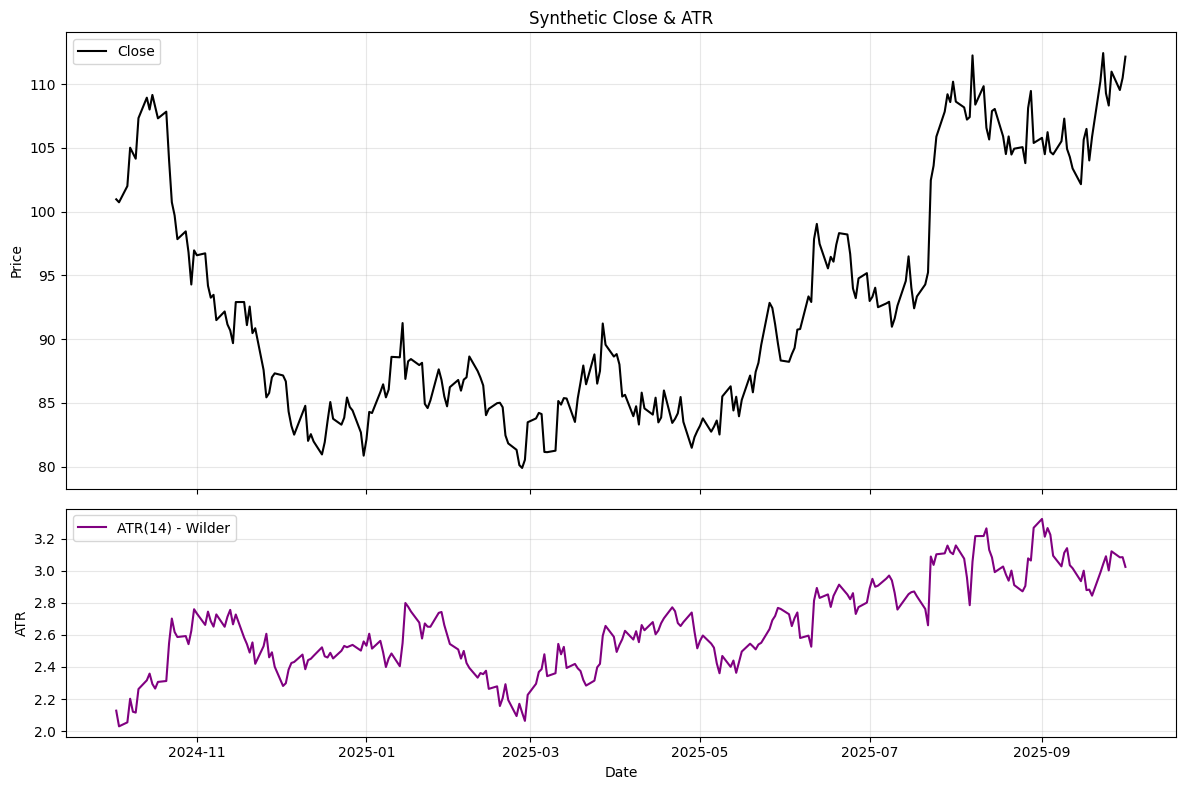

Mode: Synthetic
Rows: 260
Last Close: 112.16
Last ATR(14, wilder): 3.0242
Last True Range: 2.2352


In [2]:
# ==== ATR (Average True Range) Project ====
# Works with synthetic data by default. Set RUN_MODE="yfinance" for real prices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
RUN_MODE   = "synthetic"   # "synthetic" or "yfinance"
TICKER     = "AAPL"        # only used if RUN_MODE="yfinance"
PERIOD     = "1y"
INTERVAL   = "1d"

ATR_LEN    = 14            # typical ATR window
METHOD     = "wilder"      # "wilder" (EMA-like) or "sma"
# -------------------------

# 1) Load Data
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=False, progress=False)
        if df is None or df.empty:
            raise RuntimeError("No data returned.")
        high  = pd.to_numeric(df["High"], errors="coerce")
        low   = pd.to_numeric(df["Low"], errors="coerce")
        close = pd.to_numeric(df["Close"], errors="coerce")
        title = f"{TICKER} Close & ATR({ATR_LEN})"
    except Exception as e:
        print("Falling back to synthetic data because:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    n = 260  # ~1 trading year
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    # Generate synthetic close via GBM
    mu, sigma, dt = 0.12, 0.30, 1/252
    z = np.random.normal(size=n)
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    close_vals = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(close_vals, index=dates, name="Close")

    # Build synthetic High/Low around Close
    # Ensure H >= max(C, O) and L <= min(C, O) by adding random ranges
    rng = np.random.uniform(0.002, 0.02, size=n)
    high = pd.Series(close_vals * (1 + rng), index=dates, name="High")
    low  = pd.Series(close_vals * (1 - rng), index=dates, name="Low")

    title = "Synthetic Close & ATR"

# 2) True Range (TR) and ATR
# TR_t = max(High_t - Low_t, |High_t - Close_{t-1}|, |Low_t - Close_{t-1}|)
prev_close = close.shift(1)
tr1 = high - low
tr2 = (high - prev_close).abs()
tr3 = (low  - prev_close).abs()
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

if METHOD.lower() == "wilder":
    # Wilder's smoothing: initialize with SMA, then recursive:
    # ATR_t = (ATR_{t-1}*(n-1) + TR_t) / n
    atr = true_range.ewm(alpha=1/ATR_LEN, adjust=False).mean()
else:
    # Simple moving average of TR
    atr = true_range.rolling(ATR_LEN).mean()

# 3) Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# Price
ax1.plot(close.index, close, label="Close", color="black")
ax1.set_title(title)
ax1.set_ylabel("Price")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ATR
ax2.plot(atr.index, atr, label=f"ATR({ATR_LEN}) - {METHOD.title()}", color="purple")
ax2.set_ylabel("ATR")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 4) Summary
print("Mode:", "Real (yfinance)" if RUN_MODE=="yfinance" else "Synthetic")
print("Rows:", len(close))
print("Last Close:", round(close.iloc[-1],2))
print(f"Last ATR({ATR_LEN}, {METHOD}):", round(atr.iloc[-1],4))
print("Last True Range:", round(true_range.iloc[-1],4))
